# Градиентный спуск

In [236]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import SGDRegressor

У модели линейной регрессии $y = wX + \epsilon$ есть аналитическое решение в матричнной форме $\tilde w = (X^TX)^{-1}X^Ty$ ([вывод формулы](http://www.machinelearning.ru/wiki/index.php?title=Метод_наименьших_квадратов)), полученное методом наименьших квадратов и минимизирующее сумму квадратов ошибок $y_i - \tilde y_i ( = \tilde w X), i = \overline{1,n}$. Находить минимум суммы квадратов ошибок по $w$ также можно численно методом градиентного спуска. У градиентного спуска есть свои плюсы и минусы:

- "+" - позволяет быстро вычислить приближенные веса $w$ при больших $X$, когда аналитическое решение будет очень дорогим;
- "-" - алгоритм может несойтись при неправильном выборе параметров алгоритма.

Аналитическое решение используется редко, его полезно знать, чтобы понимать, что мы оптимизируем и как.

У градиентного спуска есть еще особенность, которую важно помнить,  - для функций ошибок, которые не выпуклы, можем застрять в локальном минимуме.

## Ручная реализация градиентного спуска

Реализуем метод градиентого спуска для поиска минимума невыпуклой функции $y = x^2(cos(x-9) - sin(x+8))$.

In [176]:
def function(x: float):
  return x**2 * (np.cos(x-9) - np.sin(x+8))

def derivative(x:float):
  return 2*x*(np.cos(x-9) - np.sin(x+8)) +  x**2 * (-np.sin(x-9) - np.cos(x+8))

def grad_descent(left: float, right: float, num_steps: int=100, effort: float=0.01, tolerance: float=0.01):
    theta = left + np.random.rand()*(right - left)
    x = [theta]
    y = [function(theta)]
    for _ in range(num_steps):
        grad_value = derivative(theta)
        theta -= grad_value * effort
        x.append(theta)
        y.append(function(theta))
        if abs(y[-1] - y[-2]) < tolerance:
            print('converged')
            break
    plt.scatter(x, y, s=20, c = 'red')
    return theta

converged


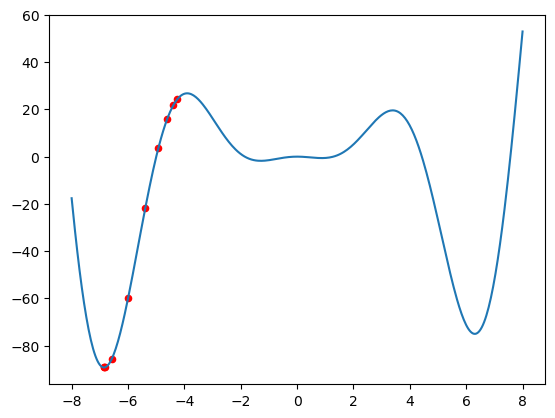

In [177]:
x = np.linspace(-8, 8, 400)
y = x**2 * (np.cos(x-9) - np.sin(x+8))
plt.plot(x, y)
grad_descent(-8, 8)
plt.show()

Видим, что градиентный спуск можно контролировать, задавая параметры:
- `tolerance` - показатель, реагирующий на необходимость досрочно остановить подбор параметров модели, когда мы считаем, что модель "сошлась";
- `effort` - показатель, задающий смещение параметра при обновлении. Этот параметр также называется learning rate или "коэффициент обучения", сокращённо: lr;
- `num_steps` - показатель, задающий количество итераций или шагов при спуске, по-другому - число эпох.

## Линейная регрессия (МНК и градиентный спуск)

### Подготовка данных

In [226]:
%%time
# Загрузим датасет с GitHub
url = "https://raw.githubusercontent.com/eilicheva-art/datasets/refs/heads/main/russian_regions_stats_2024.csv"
df = pd.read_csv(url)

# Вычисляем границы выбросов и удаляем выбросы
Q1_y = df['y'].quantile(0.25)
Q3_y = df['y'].quantile(0.75)
IQR_y = Q3_y - Q1_y
upper_bound_critical_y = Q3_y + 3 * IQR_y
df = df[df['y'] <= upper_bound_critical_y].reset_index(drop=True)

print("Количество строк", df.shape[0])
df.head()

Количество строк 82
CPU times: total: 0 ns
Wall time: 105 ms


,Регион,ФО,x1,x2,x3,x4,x5,y
0,Белгородская область,ЦФО,56798,65.40,4.4,3.466,36.980145,6.1
1,Брянская область,ЦФО,48502,69.80,9.1,3.862,33.708853,6.5
2,Владимирская область,ЦФО,46302,77.59,7.4,2.315,33.494417,6.2
3,Воронежская область,ЦФО,53449,68.50,5.4,3.972,35.584747,6.9
4,Ивановская область,ЦФО,47881,82.20,8.0,2.686,32.486338,6.9


In [227]:
%%time
# Создадим отдельно датафрейм для признаков и ряд (series) для целевого признака 
features_df = df[['x1', 'x2', 'x4', 'x5']] # извлекаем признаки
target_df = df['y'] # извлекаем целевой признак
# Стандартизация признаков
scaler = StandardScaler()
scaler.fit(features_df)
features_df_scaler = scaler.transform(features_df)

CPU times: total: 0 ns
Wall time: 2.82 ms


### МНК вручную

In [228]:
%%time
def ols_solution(X, y):
    """Функция добавляет к матрице X единичный столбец слева и затем 
    реализуется матричное умножение (X_t*X)^-1*X_t*y"""
    X = np.hstack((np.ones((X.shape[0], 1)), X))
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    return w

w_ols = ols_solution(X=features_df_scaler, y=target_df)
print("Веса: ", w_ols)

Веса:  [ 8.1097561   0.7194303  -0.24090194  0.63370119 -0.67014373]
CPU times: total: 0 ns
Wall time: 702 μs


In [229]:
w_ols.shape

(5,)

In [230]:
%%time
def prediction(X, w):
    """Функция рассчитывает оценку y по вектору весов w, оцененному по МНК по формуле X * w"""
    X = np.hstack((np.ones((X.shape[0], 1)), X))
    predict = X @ w
    return predict

prediction_ols = prediction(X=features_df_scaler, w=w_ols)
print(prediction_ols)

[ 6.97518705  7.30474949  6.69726649  7.19103211  6.91334199  7.30999538
  7.03078564  7.15399753  6.69421131  7.5541246   7.77829051  6.4703809
  7.27785779  6.73367621  6.69864478  7.00180044  7.19418912 10.32143119
  7.97382934  8.05470272 11.51375447  7.59245138  7.17540213  6.57032427
  7.70474077  8.75067976  6.17833785  6.30893171  8.03018379  8.67825135
  8.83209263  9.02675674  8.05536675  7.81953059  7.69415794  8.21429472
  8.14078172 12.99451566 10.05060228 10.06323133  9.21269031  8.36838622
  7.6750124   7.27384715  7.15687781  7.65677466  8.09475141  7.11477532
  7.98217314  6.78735312  7.25040037  7.1811909   6.75692623  7.29287428
  6.58748909  6.54480257  7.79659786  7.74641902  9.02925382 11.07295498
  7.55340229  7.32188567 10.91880968  7.86365641  8.35980626  7.94016216
  8.75494669  7.97584842  8.12645728  8.1150116   8.35407388 10.74975006
 10.55144802  9.77376386  8.98250007  8.62614868  8.18595163  8.28992439
  9.17040678  8.45139513  8.77821797 11.85099998]
CP

In [231]:
%%time
def compute_mse(y, prediction):
    """Функция рассчитывает MSE по значению y и МНК-оценке y"""
    m = len(y)
    mse = np.linalg.norm(prediction - y) ** 2 / m
    return round(mse, 2)

print("MSE:", compute_mse(y=target_df, prediction=prediction_ols))

MSE: 0.83
CPU times: total: 0 ns
Wall time: 469 μs


### LinearRegression и SGDRegressor в sklearn

In [240]:
%%time
# LinearRegression - аналитическое решение
model_lr = LinearRegression() # инициализируем модель LinearRegression
model_lr.fit(features_df_scaler, target_df) # обучим модель на тренировочной выборке
# Расчет MSE
prediction_lr = model_lr.predict(features_df_scaler) # Сделаем предсказания на обучающей выборке
mse_lr = mean_squared_error(target_df, prediction_lr) # рассчитаем MSE модели
print('Коэффициенты модели', model_lr.coef_)
print('Свобоный член', model_lr.intercept_)
print('MSE модели на обучающей выборке', round(mse_lr, 2))

Коэффициенты модели [ 0.7194303  -0.24090194  0.63370119 -0.67014373]
Свобоный член 8.109756097560977
MSE модели на обучающей выборке 0.83
CPU times: total: 0 ns
Wall time: 2.2 ms


In [241]:
%%time
# SGDRegressor - стохастический градиентный спуск
model_sgd = SGDRegressor(max_iter = 10000, alpha = 0.001) # инициализируем модель LinearRegression
model_sgd.fit(features_df_scaler, target_df) # обучим модель на тренировочной выборке
# Расчет MSE
prediction_sgd = model_sgd.predict(features_df_scaler) # Сделаем предсказания на обучающей выборке
mse_sgd = mean_squared_error(target_df, prediction_sgd) # рассчитаем MSE модели
print('Коэффициенты модели', model_lr.coef_)
print('Свобоный член', model_sgd.intercept_)
print('MSE модели на обучающей выборке', round(mse_sgd, 2))

Коэффициенты модели [ 0.7194303  -0.24090194  0.63370119 -0.67014373]
Свобоный член [8.06794222]
MSE модели на обучающей выборке 0.84
CPU times: total: 31.2 ms
Wall time: 2.37 ms


Результаты реализации МНК вручную совпадает с результатами LinearRegression из Sklearn.

MSE SGDRegressor отличается незначительно от MSE LinearRegression.

## Источники

- Градиентный спуск (базовое объяснение) - [ссылка](https://disk.yandex.ru/d/2JnF6qwRCF46mg/%D0%98%D1%81%D0%BA%D1%83%D1%81%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D1%8B%D0%B9%20%D0%B8%D0%BD%D1%82%D0%B5%D0%BB%D0%BB%D0%B5%D0%BA%D1%82/%D0%97%D0%B0%D0%BD%D1%8F%D1%82%D0%B8%D0%B5%203)
- Разновидности градиентного спуска - [ссылка1](https://github.com/evgpat/ml_basics_course/tree/main/lesson_03) [ссылка2](https://visualize-ml.ru/gradient-descent)
- Математика градиентного спуска [Ссылка](https://github.com/esokolov/ml-course-hse/blob/master/ml1-2026-spring/lecture-notes/lecture03-linregr.pdf)
- Курс на Stepik "Современный NumPy: Полное руководство | Technohub"